# PageRank - iteration by iteration in NumPy

In [1]:
import numpy as np
from sklearn.preprocessing import normalize

In [2]:
def PageRank(A,alpha,iter_num):
    node_num = len(A)
    M = normalize(A, axis=1, norm='l1')
    transition_mx = M * (1 - alpha) + (alpha) * np.ones((node_num,node_num)) / float(node_num)
    p = normalize(np.ones(node_num).reshape(1,-1),axis=1,norm='l1')
    print ("normalized A: ")
    print (M)
    print ("transition matrix transition_mx: ")
    print (transition_mx)
    p_states = np.copy(p)
    for i in range(iter_num):
        p = np.dot(p,transition_mx)
        p_states = np.concatenate((p_states,p))
    return p_states

In [3]:
A = np.array([[0,1,0,1],[0,0,1,1],[1,0,0,0],[0,0,1,0]])
print (A)

[[0 1 0 1]
 [0 0 1 1]
 [1 0 0 0]
 [0 0 1 0]]


In [4]:
p_states = PageRank(A,0.1,20)
print (p_states)

normalized A: 
[[0.  0.5 0.  0.5]
 [0.  0.  0.5 0.5]
 [1.  0.  0.  0. ]
 [0.  0.  1.  0. ]]
transition matrix transition_mx: 
[[0.025 0.475 0.025 0.475]
 [0.025 0.025 0.475 0.475]
 [0.925 0.025 0.025 0.025]
 [0.025 0.025 0.925 0.025]]
[[0.25       0.25       0.25       0.25      ]
 [0.25       0.1375     0.3625     0.25      ]
 [0.35125    0.1375     0.311875   0.199375  ]
 [0.3056875  0.1830625  0.2663125  0.2449375 ]
 [0.26468125 0.16255938 0.32782188 0.2449375 ]
 [0.32003969 0.14410656 0.31859547 0.21725828]
 [0.31173592 0.16901786 0.28538041 0.23386581]
 [0.28184237 0.16528116 0.31153727 0.2413392 ]
 [0.30538354 0.15182906 0.31658181 0.22620559]
 [0.30992363 0.16242259 0.29690811 0.23074567]
 [0.2922173  0.16446563 0.30576127 0.2375558 ]
 [0.30018515 0.15649778 0.31280975 0.23050732]
 [0.30652878 0.16008332 0.30288059 0.23050732]
 [0.29759253 0.16293795 0.30449408 0.23497544]
 [0.29904467 0.15891664 0.30979997 0.23223872]
 [0.30381998 0.1595701  0.30552733 0.23108259]
 [0.2999746  

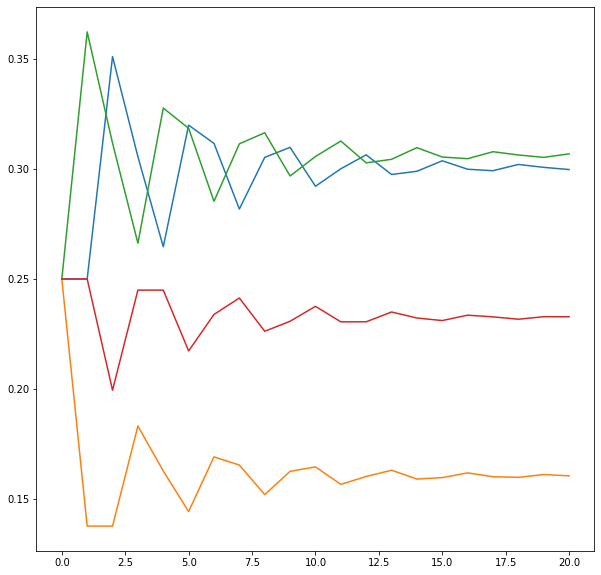

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(4):
    plt.plot(range(21),p_states[:,i])

In [6]:
p_states = PageRank(A,0.2,20)
print (p_states)

normalized A: 
[[0.  0.5 0.  0.5]
 [0.  0.  0.5 0.5]
 [1.  0.  0.  0. ]
 [0.  0.  1.  0. ]]
transition matrix transition_mx: 
[[0.05 0.45 0.05 0.45]
 [0.05 0.05 0.45 0.45]
 [0.85 0.05 0.05 0.05]
 [0.05 0.05 0.85 0.05]]
[[0.25       0.25       0.25       0.25      ]
 [0.25       0.15       0.35       0.25      ]
 [0.33       0.15       0.31       0.21      ]
 [0.298      0.182      0.278      0.242     ]
 [0.2724     0.1692     0.3164     0.242     ]
 [0.30312    0.15896    0.31128    0.22664   ]
 [0.299024   0.171248   0.294896   0.234832  ]
 [0.2859168  0.1696096  0.3063648  0.2381088 ]
 [0.29509184 0.16436672 0.30833088 0.23221056]
 [0.2966647  0.16803674 0.30151514 0.23378342]
 [0.29121211 0.16866588 0.30424143 0.23588058]
 [0.29339315 0.16648484 0.30617081 0.2339512 ]
 [0.29493665 0.16735726 0.30375489 0.2339512 ]
 [0.29300392 0.16797466 0.30410386 0.23491756]
 [0.29328309 0.16720157 0.30512392 0.23439143]
 [0.29409913 0.16731324 0.30439377 0.23419386]
 [0.29351502 0.16763965 0.304

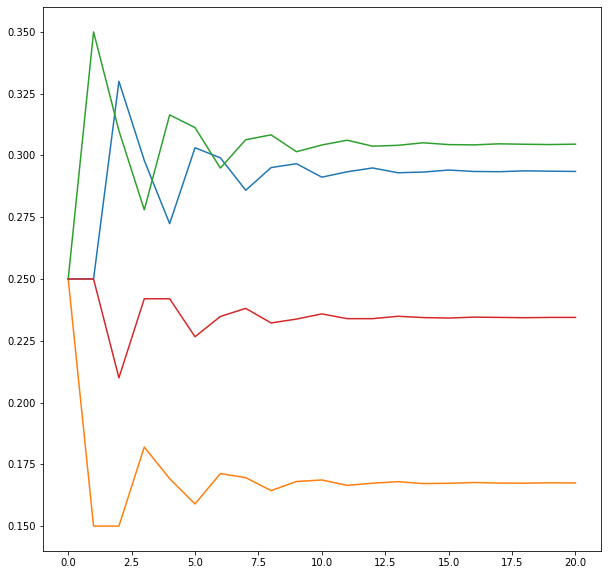

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(4):
    plt.plot(range(21),p_states[:,i])

In [8]:
import pandas as pd
import networkx as nx

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

# Moreno 7th data set from KONECT http://konect.uni-koblenz.de/ 

category: HumanSocial<br>
code: MX<br>
name: Seventh graders<br>
description: Student–student proximity<br>
entity-names: student<br>
extr: moreno<br>
url: http://moreno.ss.uci.edu/data.html#seventh<br>
long-description: This directed network contains proximity ratings between studetns from 29 seventh grade students from a school in Victoria. Among other questions the students were asked to nominate their preferred classmates for three different activities. A node represents a student. An edge between two nodes shows that the left student picked the right student as his answer. The edge weights are between 1 and 3 and show how often the left student chose the right student as his favourite.<br>
relationship-names: proximity<br>
cite: konect:duncan98

In [10]:
edge_list = pd.read_csv("/home/benczur/WWWMat2026/Data/out.moreno_seventh_seventh",header=2,sep=" ",names=["source","target","amount"])
edge_list.head()

,source,target,amount
0,1,3,1
1,1,4,2
2,1,5,2
3,1,6,3
4,1,7,3


In [11]:
edge_list['source'].max(),edge_list['target'].max(),

(29, 29)

In [12]:
# Not nice solution
AA=np.zeros((30,30))

for i in range(len(edge_list)):
    AA[edge_list.loc[i,'source'],edge_list.loc[i,'target']]=1

In [36]:
PageRank(AA,0.1,20)

normalized A: 
[[0.         0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
  0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
  0.06666667 0.06666667 0.06666667 0.         0.         0.
  0.         0.         0.         0.06666667 0.         0.
  0.         0.         0.         0.         0.        ]
 [0.05263158 0.         0.05263158 0.05263158 0.05263158 0.05263158
  0.05263158 0.05263158 0.         0.05263158 0.05263158 0.05263158
  0.         0.05263158 0.05263158 0.         0.05263158 0.
  0.05263158 0.05263158 0.05263158 0.         0.05263158 0.05263158
  0.05263158 0.         0.         0.         0.        ]
 [0.04347826 0.04347826 0.         0.04347826 0.04347826 0.04347826
  0.04347826 0.04347826 0.04347826 0.04347826 0.04347826 0.04347826
  0.04347826 0.04347826 0.04347826 0.04347826 0.04347826 0.04347826
  0.04347826 0.04347826 0.04347826 0.         0.04347826 0.
  0.04347826 0.04347826 0.         0.         0.        ]
 [0.03571429 0.03571429 0.0

array([[0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.03448276,
        0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.03448276,
        0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.03448276,
        0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.03448276,
        0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.03448276,
        0.03448276, 0.03448276, 0.03448276, 0.03448276],
       [0.02710726, 0.03705585, 0.04914411, 0.06214368, 0.06214368,
        0.03102621, 0.03580961, 0.04148695, 0.02896978, 0.04131072,
        0.02997544, 0.03406212, 0.03210726, 0.03253665, 0.04364452,
        0.01944158, 0.02706197, 0.01681843, 0.01811931, 0.03573862,
        0.03361134, 0.04853452, 0.03552764, 0.03392697, 0.03118961,
        0.03979488, 0.03672142, 0.01726041, 0.01772945],
       [0.03027274, 0.03707028, 0.04458141, 0.0541598 , 0.0541598 ,
        0.03083219, 0.03888628, 0.04084659, 0.03193258, 0.04223551,
        0.03332659, 0.03672185, 0.03507212, 0.0344308 , 0.04008544,
  

In [15]:
G=nx.from_pandas_edgelist(edge_list, "source", "target", edge_attr="amount")

In [34]:
# Nice solution
AA=nx.to_numpy_array(G)

## nx.pagerank() only for reference

In [16]:
nx.pagerank(G)

{1: 0.03019195722211817,
 3: 0.037324294171061825,
 4: 0.044847805356386404,
 5: 0.0539532227025141,
 6: 0.0539532227025141,
 7: 0.03083869313618986,
 8: 0.03857376677434468,
 9: 0.04083714810296122,
 10: 0.031871616080097497,
 11: 0.0421948226027052,
 12: 0.03339540571769156,
 13: 0.03683307827589297,
 14: 0.03513352275636887,
 15: 0.035097423452213034,
 2: 0.03988152675130732,
 16: 0.0193015857585017,
 17: 0.02466642979574438,
 18: 0.017482009662282593,
 19: 0.02050135065850953,
 20: 0.038502993982655574,
 21: 0.0353464310371984,
 22: 0.04057405641379049,
 23: 0.037071812875757684,
 24: 0.03549616285005113,
 25: 0.03370586455821684,
 26: 0.039090310724444265,
 27: 0.03568470905703891,
 28: 0.0188043122655518,
 29: 0.01884446455588992}